In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from math import comb

In [3]:
# read in tntp file as a dataframe

with open("net.tntp", "r") as file:
    for line in file:
        if line.strip().startswith("~"):
            header = line.strip().split()
            break
    df = pd.read_csv(file, sep='\s+', names=header)

df = df.rename(columns={
    '~':'Start_node',
    'init_node': 'End_node',
    'term_node': 'Capacity',
    'capacity': 'length',
    'length': 'Free_flow_time',
    'free_flow_time': 'B',
    'b': 'Power',
    'power': 'Speed',
    'speed': 'Toll',
    'toll': 'Link_type'
})

df = df.drop('link_type', axis=1)
df = df.drop(';', axis=1)
df.head()

,Start_node,End_node,Capacity,length,Free_flow_time,B,Power,Speed,Toll,Link_type
0,1,547,49500,0.86267,0.0,0.15,4,0,0,3
1,2,548,49500,0.86267,0.0,0.15,4,0,0,3
2,3,549,49500,0.86267,0.0,0.15,4,0,0,3
3,4,550,49500,0.86267,0.0,0.15,4,0,0,3
4,5,551,49500,0.86267,0.0,0.15,4,0,0,3


The other files are not relevant to my EDA:
- "flow" dataset is the best known flow solution
- "trips": this is the "origin destination demand data", which shows the volume of people traveling from one zone to another
- "node": this is simply a dictionary correlating each node to its coordinates (but it will be used later)

The first step I'll take is making an Adjacency matrix.


In [4]:
A = np.zeros((933,933))

for _, row in df.iterrows():
  s = int(row['Start_node'])
  t = int(row['End_node'])
  A[t-1, s-1] += 1 # A[i][j] = 1 if there is a path from j to i

print(A)
print("\n")
print("Number of edges:", np.sum(A))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Number of edges: 2950.0


There are 2950 links, so this is correct. Now let's check the number of strongly and weakly connected components:

In [5]:
G = nx.from_numpy_array(A, create_using=nx.DiGraph)
print(f"Number of strongly connected components: {nx.number_strongly_connected_components(G)}")
print(f"\nNumber of weakly connected components: {nx.number_weakly_connected_components(G)}")

Number of strongly connected components: 1

Number of weakly connected components: 1


In fact, I wonder. Though the network is directed, could its adjacency matrix be symmetric? Let's check it out. I'm taking this function from https://stackoverflow.com/questions/42908334/checking-if-a-matrix-is-symmetric-in-numpy

In [6]:
def check_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)

print(f"Is the adjacency matrix symmetric? {check_symmetric(A)}")

Is the adjacency matrix symmetric? True


It is! So we can honestly treat this network as an undirected network in the exploratory analysis. Every edge simply represents a "road", which means that each time we have a road, we can go in both directions.

From now on, we will treat the network as **undirected**.

Great. Now, let's move onto **density, mean degree, etc**.

In [7]:
# graph is now undirected
G = nx.from_numpy_array(A)

# number of edges = sum of degrees / 2
# connectance = number of edges / number of possible edges

p = (A.sum()/2) / comb(933, 2)
print(f"Connectance: {p}")

Connectance: 0.0033925359608811853


^ This connectance considers edges coming in both directions from each node.

Now, since we have a directed network, we can get the mean degree.  




In [8]:
# c = (n-1)*p
print(f"Mean degree from connectance: {932*p}")
print(f"Mean degree from adjacency matrix: {np.mean(np.sum(A, axis=0))}")

Mean degree from connectance: 3.1618435155412645
Mean degree from adjacency matrix: 3.1618435155412645


In [9]:
# use shilpa's code to convert node dataset to lat-long coordinates
import pandas as pd
import numpy as np
import geopandas as gpd
from pyproj import Transformer
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import networkx as nx

node_file = "node.tntp"
nodes = []
reading_date = False
with open(node_file, "r") as file:
    for line in file:
        line = line.split(";")[0]
        # print(line)
        if line.startswith("node"):
            reading_date = True
            continue
        if not reading_date or line.startswith("~") or line == "":
            continue
        parts = line.split()
        if len(parts) >= 3:
            node_id, x, y = int(parts[0]), float(parts[1]), float(parts[2])
            nodes.append((node_id, x, y))

df_nodes = pd.DataFrame(nodes, columns=["Node", "X", "Y"])
#df_nodes.head()
transformer = Transformer.from_crs("EPSG:26771", "EPSG:4326", always_xy=True)
df_nodes["Lon"], df_nodes["Lat"] = zip(*df_nodes.apply(lambda row: transformer.transform(row["X"], row["Y"]), axis=1))

# using these for downtown Chicago coordinates
downtown_coords = (41.8807553603753, -87.62988172481633)

<ipython-input-12-02cbe9f1f0f5>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned = df_nodes.groupby("Distance_bin")["Degree"].mean().reset_index()


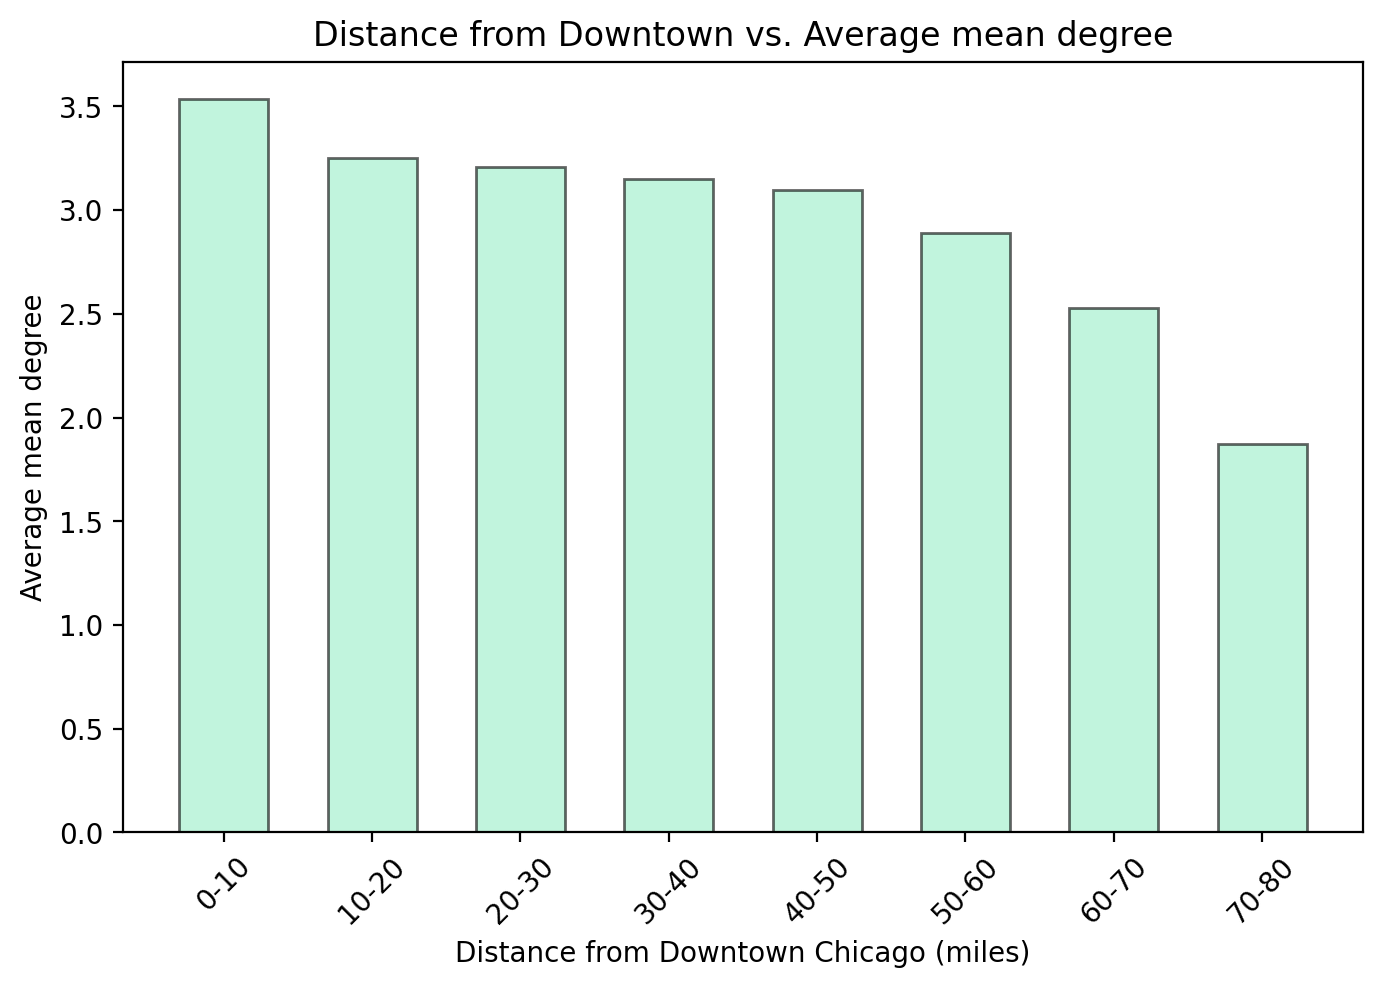

In [12]:
# now we can plot

df_nodes["Distance_from_downtown_miles"] = df_nodes.apply(
    lambda row: geodesic((row["Lat"], row["Lon"]), downtown_coords).miles, axis=1
)

df_nodes["Degree"] = A.sum(axis=1)  # row i of A corresponds to node i


# plot the graph
bins = np.arange(0, df_nodes["Distance_from_downtown_miles"].max() + 10, 10)
df_nodes["Distance_bin"] = pd.cut(df_nodes["Distance_from_downtown_miles"], bins)
df_binned = df_nodes.groupby("Distance_bin")["Degree"].mean().reset_index()
df_binned.rename(columns={"Degree": "Mean_Degree_in_bin"}, inplace=True)
plt.figure(figsize=(8, 5), dpi=200)
bin_centers = [(bin.left + bin.right) / 2 for bin in df_binned["Distance_bin"]]
plt.bar(bin_centers, df_binned["Mean_Degree_in_bin"], width=6, alpha=0.6, edgecolor="black", color="#98edc7")
plt.xticks(
    ticks=bin_centers,
    labels=[f"{int(bin.left)}-{int(bin.right)}" for bin in df_binned["Distance_bin"]],
    rotation=45
)
plt.xlabel("Distance from Downtown Chicago (miles)")
plt.ylabel("Average mean degree")
plt.title("Distance from Downtown vs. Average mean degree")
plt.show()


So, on average, for each node, there are 3 roads that you can use to get into or out of it. Note that this is the **average**. In reality, in downtown, this is probably very high, and on the outskirts of the town, this number is very low. However, we will get into different centrality measures later in the project.

Finally let's move onto **capturing groups**.

In [11]:
for num in range(1,10):
  my_str = str(nx.k_core(G, k=num))
  print(f"Size of {num}-core: {my_str[10:]}")

Size of 1-core:  933 nodes and 1475 edges
Size of 2-core:  529 nodes and 1071 edges
Size of 3-core:  475 nodes and 966 edges
Size of 4-core:  0 nodes and 0 edges
Size of 5-core:  0 nodes and 0 edges
Size of 6-core:  0 nodes and 0 edges
Size of 7-core:  0 nodes and 0 edges
Size of 8-core:  0 nodes and 0 edges
Size of 9-core:  0 nodes and 0 edges


So it looks like the largest k-core is of size 3. That means that in this network, there is some set where each node is connected to at least 3 others in the set. However, once we get to 4 and up, there is no k-core.